In [4]:
import pandas as pd
import numpy as np

# read CSV with the Date as index.
df = pd.read_csv(r'clean_portfolio_prices.csv', index_col=0, parse_dates=True)
# "index_col = 0" uses the first column (the Date) as the index.
# "parse_dates= True" converts the Date column into proper datetime objects.
# instead of using "pd.to_datetime", "parse_dates" simplifies things.

# compute daily returns
returns = df.pct_change().dropna()
# "pct_change" calculates the percentage change from one day to the next for each stock.

# equal weights
weights = [0.33, 0.5, 0.33]
# this is the allocation, or the portfolio composition

# portfolio returns
portfolio_returns = returns @ weights 
# matrix multiplying returns and weights, so it produces a single daily portfolio return series

# 95% Historical VaR
# 5th percentile of historical returns
var_95 = np.percentile(portfolio_returns, 5)
print(f"1 Day 95% Historical VaR: {var_95:.3%}")

# calculating Expected Shortfall (CVaR 95%)
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()
print(f"Expected Shortfall (CVaR 95%): {cvar_95:.3%}")
# average damage beyond the 95% cutoff


var_99 = np.percentile(portfolio_returns, 1)
print(f"1 Day 99% Historical VaR: {var_99:.3%}")

#VaR 95%
# on 95% of days, portfolio loss won't exceed 2.680%
# 95% of the times, daily losses were smaller than 2.25%

# CVaR 
# On the worst 5% of days, average loss ≈ 3.7%.
# if we cross the 95% threshold (2.680), the average damage would be 3.7%

# VaR 99%
# on the worst 1% of days, loss > 3.8%.
# only 1% of the time would your portfolio lose more than 3.8%

# Downside Tail Risk is around 2–4% per day, mild for tech stocks, but could be bad during volatility spikes.

1 Day 95% Historical VaR: -2.680%
Expected Shortfall (CVaR 95%): -3.920%
1 Day 99% Historical VaR: -4.624%


In [5]:
# daily percentage returns
returns = df.pct_change().dropna()

# portfolio weights (adjust as needed)
weights = np.array([0.33, 0.33, 0.33])

# compute historical mean & covariance
# mean daily return for each stock
mu = returns.mean().values

cov = returns.cov().values
# each stock's volatility

# Monte Carlo simulation 
n_sims = 100_000   # we are generating 100,000 plausible simulations
np.random.seed(42) # ensures random results are reproducible

# simulate multivariate normal daily returns
simulated = np.random.multivariate_normal(mean=mu, cov=cov, size=n_sims)

# Compute portfolio returns for each simulation
# matrix multiplying simulation and weights
sim_portfolio = simulated @ weights

# 95% VaR from simulated distribution
# compute 5th percentile of simulated portfolio returns
mc_var_95 = np.percentile(sim_portfolio, 5)

# average of all portfolio values that are less than or equal to the VaR.
# this is the conditional VaR or Expected Shortfall (CVaR)
mc_cvar_95 = sim_portfolio[sim_portfolio <= mc_var_95].mean()

print(f"Monte Carlo 1 Day 95% VaR: {mc_var_95:.2%}")
print(f"Monte Carlo 1 Day 95% CVaR: {mc_cvar_95:.2%}")


Monte Carlo 1 Day 95% VaR: -2.38%
Monte Carlo 1 Day 95% CVaR: -3.01%


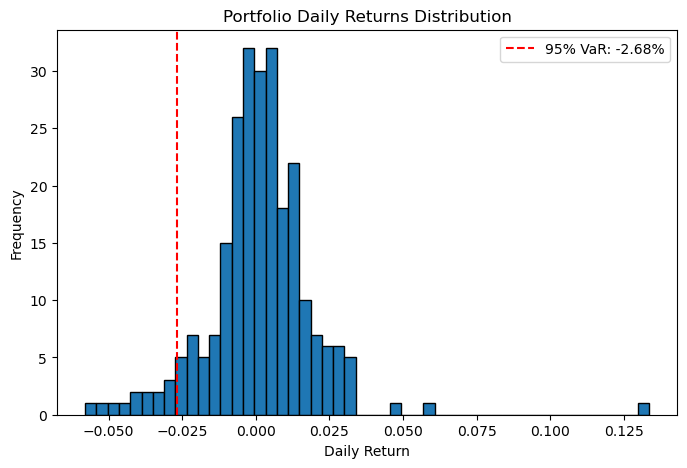

In [6]:
# a simple plot just for a rough visual
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(portfolio_returns, bins=50, edgecolor='black')
plt.axvline(var_95, color='r', linestyle='--', label=f'95% VaR: {var_95:.2%}')
plt.legend()
plt.title('Portfolio Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


